**Experiment 5**

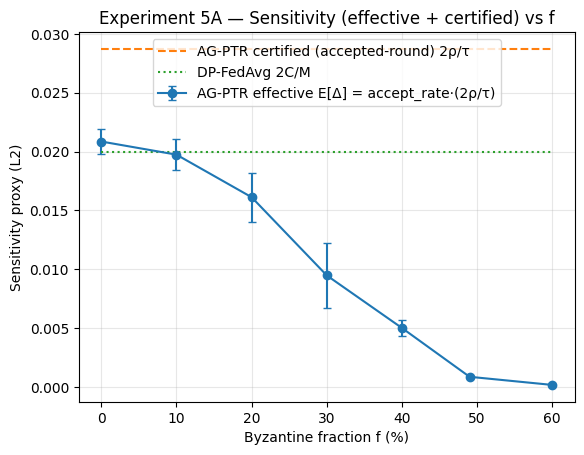

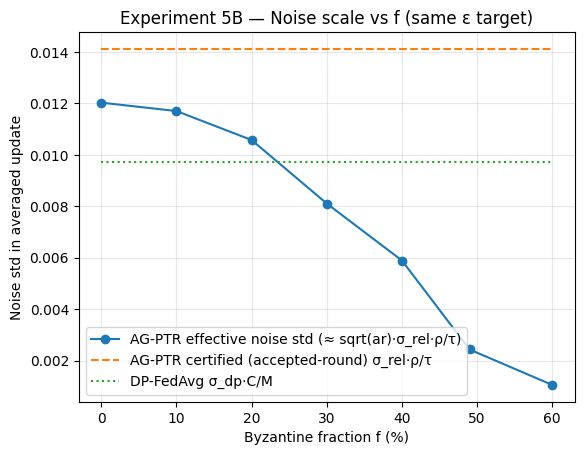

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv("exp2_summary.csv")

# constants from your Exp2
M = 100
C = 1.0
rho = 0.79
tau = 55

# your computed sigmas (paste yours, or recompute if you want)
sigma_dp  = 0.9723217465539842
sigma_rel = 0.9829512225866845

dp_sens = 2*C/M
ag_sens_cert = 2*rho/tau

dp_noise = sigma_dp*C/M
ag_noise_cert = sigma_rel*rho/tau

f_pct = summary["f"].values * 100
ar = summary["agptr_accept_rate_mean"].values
ar_std = summary["agptr_accept_rate_std"].values

# Effective over-all-rounds (rejected rounds contribute 0 release)
ag_sens_eff = ar * ag_sens_cert
ag_sens_eff_std = ar_std * ag_sens_cert

# “effective std” over all rounds (variance scales with accept prob)
ag_noise_eff = np.sqrt(np.clip(ar, 1e-12, 1.0)) * ag_noise_cert

x0, x1 = f_pct.min(), f_pct.max()

plt.figure()
plt.errorbar(f_pct, ag_sens_eff, yerr=ag_sens_eff_std, marker="o", capsize=3,
             label="AG-PTR effective E[Δ] = accept_rate·(2ρ/τ)")

plt.plot([x0, x1], [ag_sens_cert, ag_sens_cert], linestyle="--",
         label="AG-PTR certified (accepted-round) 2ρ/τ")

plt.plot([x0, x1], [dp_sens, dp_sens], linestyle=":",
         label="DP-FedAvg 2C/M")

plt.xlabel("Byzantine fraction f (%)")
plt.ylabel("Sensitivity proxy (L2)")
plt.title("Experiment 5A — Sensitivity (effective + certified) vs f")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


plt.figure()
plt.plot(f_pct, ag_noise_eff, marker="o",
         label="AG-PTR effective noise std (≈ sqrt(ar)·σ_rel·ρ/τ)")

plt.plot([x0, x1], [ag_noise_cert, ag_noise_cert], linestyle="--",
         label="AG-PTR certified (accepted-round) σ_rel·ρ/τ")

plt.plot([x0, x1], [dp_noise, dp_noise], linestyle=":",
         label="DP-FedAvg σ_dp·C/M")

plt.xlabel("Byzantine fraction f (%)")
plt.ylabel("Noise std in averaged update")
plt.title("Experiment 5B — Noise scale vs f (same ε target)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()